# Spatial Celcomen–FCI causal-hypothesis analysis

## Overview

This executed notebook evaluates whether strong stromal–tumour relationships learned by Celcomen can be assigned a reproducible direction in two spatial-transcriptomic sections, **HM11** and **T11**.

The analysis deliberately separates three types of evidence:

1. **Celcomen** provides symmetric, signed, model-derived gene relationships. These relationships remain undirected.
2. **Fast Causal Inference (FCI)** is applied independently to expression data to assess observational orientations and Partial Ancestral Graph patterns that may be compatible with latent confounding.
3. **OmniPath and KEGG** provide external, literature-curated directional priors.

Spatial coordinates are used for low-order spatial residualisation and spatial-block resampling. No stromal-to-tumour direction is imposed in advance. All arrows are interpreted as hypotheses rather than experimentally proven causal effects.

## Main executed finding

The analysis completed successfully for both sections, including 100 primary spatial-block FCI resamples and two sensitivity analyses. Strong undirected Celcomen relationships were identified, but **no exact FCI arrow and no bidirected pattern passed the prespecified 70% stability criteria** in either HM11 or T11. OmniPath supplied limited curated directional support, while no eligible KEGG cross-programme direction was recovered.

The defensible conclusion is therefore that **functional candidates were prioritised, but causal direction could not be resolved robustly from the current data**.


## Results at a glance

| Result | HM11 | T11 |
|---|---:|---:|
| Expression spots | 3,921 | 2,768 |
| Primary FCI panel | 9 stromal + 9 tumour genes | 9 stromal + 9 tumour genes |
| Targeted stromal–tumour pairs | 81 | 81 |
| Primary spatial-block FCI runs | 100/100 successful | 100/100 successful |
| Depth-3 sensitivity runs | 15/15 successful | 15/15 successful |
| Expanded-panel sensitivity runs | 15/15 successful | 15/15 successful |
| Stable exact FCI arrows | 0 | 0 |
| Stable bidirected patterns | 0 | 0 |
| OmniPath-supported candidate pairs | 1 | 4 |
| KEGG-supported candidate pairs | 0 | 0 |

The absence of stable arrows is a **negative causal-orientation result**, not a computational failure. It indicates that arrows appearing in individual resamples were not sufficiently reproducible to support a stable direction.


## 0. Setup and run configuration

The primary analysis uses 100 depth-2 spatial-block FCI stability resamples. Two smaller robustness analyses are also run:

- 15 depth-3 spatial-block resamples on the same targeted panel;
- 15 depth-2 spatial-block resamples on an expanded panel of up to 12 stromal and 12 tumour genes.

Coordinates are required by default. This prevents the notebook from silently falling back to IID spot subsampling.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import sys, subprocess, importlib.util
_REQUIRED = [
    ("causallearn", "causal-learn"),
    ("networkx", "networkx"),
    ("omnipath", "omnipath"),
    ("requests", "requests"),
    ("matplotlib", "matplotlib"),
    ("pandas", "pandas"),
    ("threadpoolctl", "threadpoolctl"),
    ("scipy", "scipy"),
    ("anndata", "anndata"),
]
for module, package in _REQUIRED:
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

import contextlib
import glob
import hashlib
import io
import json
import pickle
import re
import time
from collections import defaultdict
from xml.etree import ElementTree as ET

import numpy as np
import pandas as pd

# ------------------------- main settings -------------------------
SECTIONS = ["HM11", "T11"]
PANEL_PER_SIDE = 9
EXPANDED_PANEL_PER_SIDE = 12

N_RESAMPLES = 100
SUBSAMPLE = 400
FCI_DEPTH = 2

RUN_DEPTH_SENSITIVITY = True
SENSITIVITY_RESAMPLES = 15
SENSITIVITY_SUBSAMPLE = 300
SENSITIVITY_DEPTH = 3

RUN_EXPANDED_PANEL_SENSITIVITY = True
EXPANDED_PANEL_RESAMPLES = 15
EXPANDED_PANEL_SUBSAMPLE = 300
EXPANDED_PANEL_DEPTH = 2

ALPHA = 0.05
CI_TEST = "fisherz"
MAX_PATH_LENGTH = -1

MIN_ADJACENCY_STABILITY = 0.70
MIN_TYPE_STABILITY = 0.70
MIN_ARROW_STABILITY = 0.70
FUNCTIONAL_QUANTILE = 0.90

REQUIRE_COORDINATES = True
ALLOW_ROW_ORDER_COORDINATE_ALIGNMENT = False
SPATIAL_BLOCK_FRACTION = 0.70
SPATIAL_GRID_BINS = 5
SPATIAL_RESIDUALISE = True
USE_TECHNICAL_COVARIATES = True

TOP_BASE_EDGES = 25
MAX_FINAL_EDGES = 45

# KEGG uses two bulk lookups plus a bounded set of relevant KGML pathways.
KEGG_TOTAL_SECONDS = 120
KEGG_CONNECT_TIMEOUT = 3
KEGG_READ_TIMEOUT = 15
KEGG_MAX_PATHWAYS = 80

CACHE_VERSION = 5
DB_CACHE_VERSION = 6

OUT = os.path.join(os.getcwd(), "unified_causality_spatial")
os.makedirs(OUT, exist_ok=True)

def find(name):
    hits = sorted(glob.glob(os.path.join(os.getcwd(), "**", name), recursive=True))
    return hits[0] if hits else None

print("Output directory:", OUT)
print(f"Primary FCI: {N_RESAMPLES} spatial-block resamples, depth={FCI_DEPTH}, "
      f"up to {SUBSAMPLE} spots")
print(f"Depth sensitivity: {SENSITIVITY_RESAMPLES} resamples, depth={SENSITIVITY_DEPTH}")
print(f"Expanded-panel sensitivity: {EXPANDED_PANEL_RESAMPLES} resamples, "
      f"up to {EXPANDED_PANEL_PER_SIDE}+{EXPANDED_PANEL_PER_SIDE} genes")

Output directory: unified_causality_spatial
Primary FCI: 100 spatial-block resamples, depth=2, up to 400 spots
Depth sensitivity: 15 resamples, depth=3
Expanded-panel sensitivity: 15 resamples, up to 12+12 genes


## 1. Load Celcomen exports and verify spatial alignment

For each section, the notebook loads:

- `W_<section>.npy`: the signed, symmetric Celcomen coupling matrix;
- `expr_<section>.npy`: the spot-by-gene expression matrix;
- `sec_meta_<section>.json`: gene names and stromal/tumour programme annotations;
- `<section>_spots.csv`: spatial coordinates and spot annotations;
- the original section `.h5ad`, when available, to verify barcode order.

The spot CSV is aligned by identifier. When ordered spot IDs are absent from the JSON metadata, the notebook compares the CSV barcodes directly with `adata.obs_names` from the original H5AD. It either confirms the exact order or explicitly reorders the CSV to the H5AD order. It does not silently assume row-order alignment.


In [2]:
def _unique_preserve(values):
    return list(dict.fromkeys(str(v).upper() for v in values))

def _normalise_name(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).strip().lower()).strip("_")

def _array_digest(array):
    if array is None:
        return "none"
    contiguous = np.ascontiguousarray(np.asarray(array))
    return hashlib.sha1(contiguous.view(np.uint8)).hexdigest()[:16]

def find_spot_csv(section):
    exact = find(f"{section}_spots.csv")
    if exact:
        return exact
    candidates = sorted(glob.glob(os.path.join(os.getcwd(), "**", "*.csv"), recursive=True))
    section_lower = section.lower()
    for path in candidates:
        base = os.path.basename(path).lower()
        if section_lower in base and "spot" in base:
            return path
    return None


def find_h5ad(section):
    """Locate the original section-specific AnnData file when available."""
    preferred_names = (
        f"IU_PDA_{section}.h5ad",
        f"{section}.h5ad",
    )
    for name in preferred_names:
        path = find(name)
        if path:
            return path

    section_lower = section.lower()
    for path in sorted(glob.glob(os.path.join(os.getcwd(), "**", "*.h5ad"), recursive=True)):
        if section_lower in os.path.basename(path).lower():
            return path
    return None

def _h5ad_spot_ids(section, n_rows):
    """Read ordered observation identifiers without loading the full expression matrix."""
    path = find_h5ad(section)
    if path is None:
        return None, None

    import anndata as ad
    adata = ad.read_h5ad(path, backed="r")
    try:
        ids = pd.Index([str(value).strip() for value in adata.obs_names], name="h5ad_obs_names")
        if len(ids) != n_rows:
            raise ValueError(
                f"{section}: H5AD contains {len(ids)} spots but expression contains {n_rows} rows"
            )
        return ids, path
    finally:
        if getattr(adata, "file", None) is not None:
            adata.file.close()

def _meta_spot_ids(meta, n_rows):
    for key in (
        "spot_ids", "barcodes", "obs_names", "spot_names", "cell_ids",
        "cells", "obs_index", "index",
    ):
        values = meta.get(key)
        if isinstance(values, (list, tuple)) and len(values) == n_rows:
            return pd.Index([str(v).strip() for v in values], name=key), key
    return None, None

def _csv_id_column(frame):
    normalised = {_normalise_name(column): column for column in frame.columns}
    for candidate in (
        "barcode", "barcodes", "spot_id", "spot", "spot_name", "obs_name",
        "cell_id", "cell", "index", "unnamed_0",
    ):
        column = normalised.get(candidate)
        if column is None:
            continue
        values = frame[column].astype(str).str.strip()
        if values.notna().all() and values.is_unique:
            return column
    return None

def align_spot_table(frame, meta, n_rows, section):
    """Align spot annotations to expression rows using identifiers, never by silent assumption."""
    frame = frame.copy()
    meta_ids, meta_id_key = _meta_spot_ids(meta, n_rows)
    csv_id_column = _csv_id_column(frame)

    if csv_id_column is None:
        raise ValueError(f"{section}: no unique spot/barcode identifier column was found")

    csv_ids = pd.Index(
        frame[csv_id_column].astype(str).str.strip(),
        name=csv_id_column,
    )
    indexed = frame.assign(__spot_id=csv_ids).set_index("__spot_id", drop=False)

    # Preferred route: ordered identifiers exported with the Celcomen metadata.
    if meta_ids is not None:
        missing = meta_ids.difference(indexed.index)
        extra = indexed.index.difference(meta_ids)
        if len(missing) or len(extra):
            raise ValueError(
                f"{section}: spot identifiers differ between metadata and CSV "
                f"({len(missing)} missing; {len(extra)} extra)"
            )
        aligned = indexed.loc[list(meta_ids)].reset_index(drop=True)
        return aligned, "identifier_join", f"meta:{meta_id_key}; csv:{csv_id_column}"

    # Independent verification route: compare the CSV to the original H5AD observation order.
    h5ad_ids, h5ad_path = _h5ad_spot_ids(section, n_rows)
    if h5ad_ids is not None:
        missing = h5ad_ids.difference(indexed.index)
        extra = indexed.index.difference(h5ad_ids)
        if len(missing) or len(extra):
            raise ValueError(
                f"{section}: spot identifiers differ between H5AD and CSV "
                f"({len(missing)} missing; {len(extra)} extra)"
            )

        exact_order = np.array_equal(csv_ids.to_numpy(), h5ad_ids.to_numpy())
        aligned = indexed.loc[list(h5ad_ids)].reset_index(drop=True)

        if exact_order:
            method = "verified_against_h5ad"
            detail = f"csv:{csv_id_column}; exact H5AD order confirmed"
        else:
            method = "identifier_join_h5ad"
            detail = f"csv:{csv_id_column}; reordered to H5AD obs_names"

        return aligned, method, detail

    if len(frame) == n_rows and ALLOW_ROW_ORDER_COORDINATE_ALIGNMENT:
        return frame.reset_index(drop=True), "row_order_assumed", csv_id_column

    raise ValueError(
        f"{section}: exact spatial alignment could not be verified. "
        "Provide ordered spot IDs in sec_meta_<section>.json or the original section H5AD file."
    )

def detect_coordinate_columns(frame):
    normalised = {_normalise_name(column): column for column in frame.columns}
    # Prefer physical pixel coordinates, then generic spatial coordinates, then array-grid coordinates.
    candidates = (
        ("pxl_col_in_fullres", "pxl_row_in_fullres", "full_resolution_pixels"),
        ("imagecol", "imagerow", "image_pixels"),
        ("pixel_x", "pixel_y", "pixel_coordinates"),
        ("spatial_x", "spatial_y", "spatial_xy"),
        ("x_coord", "y_coord", "xy_coordinates"),
        ("coord_x", "coord_y", "xy_coordinates"),
        ("x", "y", "xy_coordinates"),
        ("array_col", "array_row", "visium_array_grid"),
        ("col", "row", "row_col_grid"),
    )
    for x_name, y_name, label in candidates:
        x_column, y_column = normalised.get(x_name), normalised.get(y_name)
        if x_column is None or y_column is None:
            continue
        x = pd.to_numeric(frame[x_column], errors="coerce")
        y = pd.to_numeric(frame[y_column], errors="coerce")
        if x.notna().all() and y.notna().all() and x.nunique() > 2 and y.nunique() > 2:
            return x_column, y_column, label
    return None, None, None

TECHNICAL_COVARIATE_ALIASES = {
    "total_counts": {"total_counts", "n_counts", "library_size", "umi_count", "n_umis"},
    "detected_genes": {"n_genes_by_counts", "n_genes", "detected_genes", "gene_count"},
    "mitochondrial_fraction": {"pct_counts_mt", "percent_mito", "mito_percent", "pct_mito"},
    "ribosomal_fraction": {"pct_counts_ribo", "percent_ribo", "ribo_percent"},
}

def extract_technical_covariates(frame):
    if not USE_TECHNICAL_COVARIATES:
        return pd.DataFrame(index=np.arange(len(frame)))
    normalised = {_normalise_name(column): column for column in frame.columns}
    output = {}
    for canonical, aliases in TECHNICAL_COVARIATE_ALIASES.items():
        column = next((normalised.get(alias) for alias in aliases if normalised.get(alias)), None)
        if column is None:
            continue
        values = pd.to_numeric(frame[column], errors="coerce")
        if values.notna().sum() < max(20, int(0.8 * len(frame))) or values.nunique(dropna=True) < 3:
            continue
        values = values.fillna(values.median()).astype(float)
        if canonical in {"total_counts", "detected_genes"}:
            values = np.log1p(np.clip(values, 0, None))
        output[canonical] = values.to_numpy()
    return pd.DataFrame(output)

def load_spot_context(section, meta, n_rows):
    # 1) Coordinates embedded in metadata.
    coords = None
    coordinate_source = None
    alignment_method = "metadata_embedded"
    alignment_detail = "metadata"
    spot_table_path = None
    aligned_table = None

    for key in ("coords", "coordinates", "spatial_coords", "spot_coordinates", "xy"):
        value = meta.get(key)
        if value is None:
            continue
        arr = np.asarray(value, dtype=float)
        if arr.ndim == 2 and arr.shape[0] == n_rows and arr.shape[1] >= 2:
            coords = arr[:, :2]
            coordinate_source = f"sec_meta:{key}"
            break

    # 2) Already aligned coordinate arrays.
    if coords is None:
        for filename in (
            f"coords_{section}.npy", f"spatial_coords_{section}.npy", f"positions_{section}.npy"
        ):
            path = find(filename)
            if not path:
                continue
            arr = np.asarray(np.load(path), dtype=float)
            if arr.ndim == 2 and arr.shape[0] == n_rows and arr.shape[1] >= 2:
                coords = arr[:, :2]
                coordinate_source = path
                alignment_method = "prealigned_npy"
                alignment_detail = filename
                break

    # 3) Spot annotation CSV. Load it even when coordinates were already available,
    #    because it may contain technical covariates.
    spot_table_path = find_spot_csv(section)
    technical = pd.DataFrame(index=np.arange(n_rows))
    if spot_table_path:
        raw_table = pd.read_csv(spot_table_path)
        aligned_table, csv_alignment, csv_detail = align_spot_table(raw_table, meta, n_rows, section)
        technical = extract_technical_covariates(aligned_table)
        if coords is None:
            x_column, y_column, coordinate_label = detect_coordinate_columns(aligned_table)
            if x_column is not None:
                coords = aligned_table[[x_column, y_column]].apply(
                    pd.to_numeric, errors="coerce"
                ).to_numpy(dtype=float)
                coordinate_source = f"{spot_table_path} [{x_column}, {y_column}]"
                alignment_method = csv_alignment
                alignment_detail = csv_detail
        elif alignment_method == "metadata_embedded":
            # Preserve the stronger coordinate source but report the CSV alignment separately.
            alignment_detail = f"{alignment_detail}; spot CSV {csv_alignment} ({csv_detail})"

    if coords is not None:
        if coords.shape != (n_rows, 2) or not np.isfinite(coords).all():
            raise ValueError(f"{section}: invalid coordinate matrix {coords.shape}")
        if np.unique(coords, axis=0).shape[0] < max(10, int(0.5 * n_rows)):
            raise ValueError(f"{section}: too many duplicated or non-informative coordinates")

    if REQUIRE_COORDINATES and coords is None:
        raise FileNotFoundError(
            f"{section}: spatial coordinates were required but not found. Expected "
            f"{section}_spots.csv or coords_{section}.npy."
        )

    return {
        "coords": coords,
        "coordinate_source": coordinate_source or "none",
        "coordinate_alignment": alignment_method if coords is not None else "none",
        "coordinate_alignment_detail": alignment_detail,
        "spot_table_path": spot_table_path,
        "technical_covariates": technical.reset_index(drop=True),
    }

data = {}
coordinate_audit_rows = []
for section in SECTIONS:
    w_path = find(f"W_{section}.npy")
    e_path = find(f"expr_{section}.npy")
    m_path = find(f"sec_meta_{section}.json")

    if not (w_path and e_path and m_path):
        print(f"{section}: missing W, expression, or metadata export; section skipped")
        continue

    with open(m_path, encoding="utf-8") as handle:
        meta = json.load(handle)

    W = np.asarray(np.load(w_path), dtype=float)
    expr = np.asarray(np.load(e_path), dtype=float)
    genes = [str(g).upper() for g in meta["gene_names"]]

    if W.shape != (len(genes), len(genes)):
        raise ValueError(f"{section}: W shape {W.shape} does not match {len(genes)} genes")
    if expr.ndim != 2 or expr.shape[1] != len(genes):
        raise ValueError(f"{section}: expression shape {expr.shape} does not match gene list")
    if not np.isfinite(W).all() or not np.isfinite(expr).all():
        raise ValueError(f"{section}: non-finite values found")

    stroma = _unique_preserve(genes[i] for i in meta.get("fib_genes", []))
    tumour = _unique_preserve(genes[i] for i in meta.get("tum_genes", []))
    context = load_spot_context(section, meta, len(expr))

    data[section] = {
        "W": W,
        "expr": expr,
        "coords": context["coords"],
        "technical_covariates": context["technical_covariates"],
        "coordinate_source": context["coordinate_source"],
        "coordinate_alignment": context["coordinate_alignment"],
        "coordinate_alignment_detail": context["coordinate_alignment_detail"],
        "spot_table_path": context["spot_table_path"],
        "genes": genes,
        "gene_index": {g: i for i, g in enumerate(genes)},
        "stroma": stroma,
        "tumour": tumour,
        "paths": {"W": w_path, "expr": e_path, "meta": m_path},
    }

    overlap = sorted(set(stroma) & set(tumour))
    technical_names = list(context["technical_covariates"].columns)
    print(f"\n{section}")
    print(f"  W: {W.shape}; expression: {expr.shape}; symmetric={np.allclose(W, W.T)}")
    print(f"  stromal annotations: {len(stroma)}; tumour annotations: {len(tumour)}")
    print(f"  annotation overlap: {len(overlap)} genes")
    print(f"  coordinates: {context['coordinate_source']}")
    print(f"  alignment: {context['coordinate_alignment']} ({context['coordinate_alignment_detail']})")
    print(f"  technical covariates used when available: {technical_names or 'none'}")
    print("  Celcomen contributes magnitude/sign only; no arrow is inferred")

    coordinate_audit_rows.append({
        "section": section,
        "n_expression_rows": len(expr),
        "coordinate_source": context["coordinate_source"],
        "alignment_method": context["coordinate_alignment"],
        "alignment_detail": context["coordinate_alignment_detail"],
        "spot_table_path": context["spot_table_path"],
        "technical_covariates": "; ".join(technical_names) if technical_names else "none",
        "coordinate_digest": _array_digest(context["coords"]),
    })

if not data:
    raise FileNotFoundError(
        "No complete W_<section>.npy, expr_<section>.npy, sec_meta_<section>.json set was found."
    )

coordinate_audit = pd.DataFrame(coordinate_audit_rows)
coordinate_audit.to_csv(os.path.join(OUT, "spatial_coordinate_audit.csv"), index=False)
print("\nSpatial coordinate audit saved: spatial_coordinate_audit.csv")


HM11
  W: (117, 117); expression: (3921, 117); symmetric=True
  stromal annotations: 26; tumour annotations: 29
  annotation overlap: 0 genes
  coordinates: handoff_to_eva/spot_annotations/HM11_spots.csv [spatial_x, spatial_y]
  alignment: verified_against_h5ad (barcode; exact H5AD order confirmed)
  technical covariates used when available: none
  Celcomen contributes magnitude/sign only; no arrow is inferred

T11
  W: (117, 117); expression: (2768, 117); symmetric=True
  stromal annotations: 101; tumour annotations: 34
  annotation overlap: 18 genes
  coordinates: handoff_to_eva/spot_annotations/T11_spots.csv [spatial_x, spatial_y]
  alignment: verified_against_h5ad (barcode; exact H5AD order confirmed)
  technical covariates used when available: none
  Celcomen contributes magnitude/sign only; no arrow is inferred

Spatial coordinate audit saved: spatial_coordinate_audit.csv


## 2. Prespecified targeted and expanded FCI panels

FCI does not discover which genes to test. It evaluates relationships among transparent, prespecified panels of canonical stromal-programme and tumour-programme genes.

- The **primary panel** contains up to 9 genes per programme.
- The **expanded-panel sensitivity analysis** contains up to 12 genes per programme and tests whether primary orientations are sensitive to adding measured genes.

In [3]:
CANONICAL_STROMA = [
    "THBS1", "TIMP1", "BGN", "ACTA2", "COL1A1", "COL3A1",
    "TAGLN", "SPARC", "IGFBP7", "CCN2", "SERPINE1", "DCN",
    "LUM", "VIM", "INHBA", "MYL9",
]
CANONICAL_TUMOUR = [
    "KRT8", "KRT18", "EPCAM", "ITGA3", "GPRC5A", "MUC1",
    "S100A6", "CLDN4", "TSPAN8", "LGALS4", "ELF3", "ERBB3",
    "FXYD3", "TMPRSS4", "LCN2", "ABCC3",
]

panel_audit_rows = []
for section, d in data.items():
    stroma_set = set(d["stroma"])
    tumour_set = set(d["tumour"])

    fci_stroma = [g for g in CANONICAL_STROMA if g in stroma_set][:PANEL_PER_SIDE]
    fci_tumour = [g for g in CANONICAL_TUMOUR if g in tumour_set][:PANEL_PER_SIDE]
    expanded_stroma = [g for g in CANONICAL_STROMA if g in stroma_set][:EXPANDED_PANEL_PER_SIDE]
    expanded_tumour = [g for g in CANONICAL_TUMOUR if g in tumour_set][:EXPANDED_PANEL_PER_SIDE]

    if set(fci_stroma) & set(fci_tumour):
        raise ValueError(f"{section}: primary FCI stromal and tumour panels overlap")
    if set(expanded_stroma) & set(expanded_tumour):
        raise ValueError(f"{section}: expanded FCI stromal and tumour panels overlap")

    d["fci_stroma"] = fci_stroma
    d["fci_tumour"] = fci_tumour
    d["fci_panel"] = fci_stroma + fci_tumour
    d["expanded_fci_stroma"] = expanded_stroma
    d["expanded_fci_tumour"] = expanded_tumour
    d["expanded_fci_panel"] = expanded_stroma + expanded_tumour

    for programme, candidates, annotations, selected, expanded_selected in (
        ("stromal_programme", CANONICAL_STROMA, stroma_set, fci_stroma, expanded_stroma),
        ("tumour_programme", CANONICAL_TUMOUR, tumour_set, fci_tumour, expanded_tumour),
    ):
        for order, gene in enumerate(candidates, start=1):
            panel_audit_rows.append({
                "section": section,
                "gene": gene,
                "programme": programme,
                "canonical_order": order,
                "present_in_expression": gene in d["gene_index"],
                "present_in_upstream_annotation": gene in annotations,
                "included_in_primary_fci": gene in selected,
                "included_in_expanded_fci": gene in expanded_selected,
            })

    print(f"\n{section}: primary panel = {len(fci_stroma)} stromal + {len(fci_tumour)} tumour")
    print(f"  primary targeted cross-pairs: {len(fci_stroma) * len(fci_tumour)}")
    print("  primary stromal:", fci_stroma)
    print("  primary tumour: ", fci_tumour)
    print(f"  expanded panel = {len(expanded_stroma)} stromal + {len(expanded_tumour)} tumour")

panel_audit = pd.DataFrame(panel_audit_rows)
panel_audit.to_csv(os.path.join(OUT, "FCI_gene_panel_audit.csv"), index=False)
print("\nPanel audit saved: FCI_gene_panel_audit.csv")


HM11: primary panel = 9 stromal + 9 tumour
  primary targeted cross-pairs: 81
  primary stromal: ['THBS1', 'TIMP1', 'BGN', 'ACTA2', 'COL1A1', 'COL3A1', 'TAGLN', 'SPARC', 'IGFBP7']
  primary tumour:  ['KRT8', 'KRT18', 'EPCAM', 'ITGA3', 'GPRC5A', 'MUC1', 'S100A6', 'CLDN4', 'TSPAN8']
  expanded panel = 12 stromal + 12 tumour

T11: primary panel = 9 stromal + 9 tumour
  primary targeted cross-pairs: 81
  primary stromal: ['THBS1', 'TIMP1', 'BGN', 'ACTA2', 'COL1A1', 'COL3A1', 'TAGLN', 'SPARC', 'IGFBP7']
  primary tumour:  ['KRT8', 'KRT18', 'EPCAM', 'ITGA3', 'GPRC5A', 'MUC1', 'S100A6', 'TSPAN8', 'LGALS4']
  expanded panel = 12 stromal + 12 tumour

Panel audit saved: FCI_gene_panel_audit.csv


## 3. Unique stromal–tumour pair table

Some genes may appear in both broad upstream annotations. To prevent double counting, unordered gene pairs are created once. Pairs with overlapping programme annotations are explicitly flagged rather than silently treated as unambiguous stromal-to-tumour pairs.

In [4]:
def perturbation_panel(W, alpha_fraction=0.8):
    """Symmetric resolvent diffusion score; not an identified intervention effect."""
    spectral_radius = float(np.max(np.abs(np.linalg.eigvals(W))))
    alpha = alpha_fraction / (spectral_radius + 1e-12)
    return np.linalg.inv(np.eye(W.shape[0]) - alpha * W) - np.eye(W.shape[0])

def unique_cross_pairs(stroma, tumour):
    stroma_set, tumour_set = set(stroma), set(tumour)
    keys = {
        tuple(sorted((a, b)))
        for a in stroma_set
        for b in tumour_set
        if a != b
    }

    rows = []
    for x, y in sorted(keys):
        xy = x in stroma_set and y in tumour_set
        yx = y in stroma_set and x in tumour_set
        if xy and not yx:
            a, b, status = x, y, "unambiguous"
        elif yx and not xy:
            a, b, status = y, x, "unambiguous"
        else:
            # Both genes carry both broad annotations. Keep one unordered pair and flag it.
            a, b, status = x, y, "overlapping_annotations"
        rows.append((a, b, status))
    return rows

pairs = {}
for section, d in data.items():
    W = d["W"]
    M = perturbation_panel(W)
    d["M"] = M
    gi = d["gene_index"]

    rows = []
    for gene_a, gene_b, role_status in unique_cross_pairs(d["stroma"], d["tumour"]):
        i, j = gi[gene_a], gi[gene_b]
        w = float(W[i, j])
        influence = float(M[i, j])

        in_targeted_cross_panel = bool(
            (gene_a in d["fci_stroma"] and gene_b in d["fci_tumour"])
            or (gene_b in d["fci_stroma"] and gene_a in d["fci_tumour"])
        )
        in_expanded_cross_panel = bool(
            (gene_a in d["expanded_fci_stroma"] and gene_b in d["expanded_fci_tumour"])
            or (gene_b in d["expanded_fci_stroma"] and gene_a in d["expanded_fci_tumour"])
        )

        rows.append({
            "section": section,
            "gene_a": gene_a,
            "gene_b": gene_b,
            "role_status": role_status,
            "celcomen_coupling": w,
            "celcomen_influence": influence,
            "celcomen_sign": "negative" if w < 0 else ("positive" if w > 0 else "zero"),
            "celcomen_magnitude": abs(w),
            "in_fci_panel": in_targeted_cross_panel,
            "in_expanded_fci_panel": in_expanded_cross_panel,
        })

    df = pd.DataFrame(rows).sort_values("celcomen_magnitude", ascending=False).reset_index(drop=True)
    pairs[section] = df

    print(f"\n{section}: {len(df)} unique candidate pairs")
    print(f"  unambiguous roles: {(df.role_status == 'unambiguous').sum()}")
    print(f"  overlapping annotations: {(df.role_status == 'overlapping_annotations').sum()}")
    print(f"  exact targeted FCI cross-pairs: {df.in_fci_panel.sum()}")
    expected = len(d["fci_stroma"]) * len(d["fci_tumour"])
    if int(df.in_fci_panel.sum()) != expected:
        raise AssertionError(
            f"{section}: expected {expected} targeted FCI pairs, found {df.in_fci_panel.sum()}"
        )


HM11: 754 unique candidate pairs
  unambiguous roles: 754
  overlapping annotations: 0
  exact targeted FCI cross-pairs: 81

T11: 3263 unique candidate pairs
  unambiguous roles: 3110
  overlapping annotations: 153
  exact targeted FCI cross-pairs: 81


## 4. OmniPath and KEGG directional priors

Database arrows remain separate from data-derived FCI orientations. OmniPath is queried in bulk. KEGG uses bulk human-gene and gene–pathway lookups, followed by a bounded number of relevant KGML pathway downloads. The cache records the exact candidate-gene set so an incomplete older cache cannot be reused silently.

In [5]:
GENE_ALIASES = {
    "CCN2": {"CCN2", "CTGF"},
    "CCN1": {"CCN1", "CYR61"},
    "SERPINE1": {"SERPINE1", "PAI1", "PAI-1", "PLANH1"},
    "TAGLN": {"TAGLN", "SM22", "SM22A"},
    "THBS1": {"THBS1", "TSP1", "TSP-1"},
    "S100A6": {"S100A6", "CACY"},
    "SPARC": {"SPARC", "ON", "BM40"},
}

wanted = {
    str(g).upper()
    for df in pairs.values()
    for g in pd.concat([df.gene_a, df.gene_b], ignore_index=True)
}
wanted_fingerprint = hashlib.sha1("|".join(sorted(wanted)).encode()).hexdigest()[:16]
alias_to_canon = {g: g for g in wanted}
for canonical_name, aliases in GENE_ALIASES.items():
    if canonical_name in wanted:
        for alias in aliases:
            alias_to_canon[alias.upper()] = canonical_name

def canon(symbol):
    return alias_to_canon.get(str(symbol).upper(), str(symbol).upper())

def aliases_of(gene):
    return {a.upper() for a in GENE_ALIASES.get(gene, {gene})} | {gene.upper()}

def normalise_edge_store(store):
    out = {}
    for key, value in dict(store).items():
        values = value if isinstance(value, (set, list, tuple, np.ndarray)) else [value]
        out[tuple(key)] = {int(v) for v in values}
    return out

DB_CACHE = os.path.join(OUT, f"database_edges_v{DB_CACHE_VERSION}.pkl")
cached_db = None
if os.path.exists(DB_CACHE):
    with open(DB_CACHE, "rb") as handle:
        candidate = pickle.load(handle)
    if candidate.get("wanted_fingerprint") == wanted_fingerprint:
        cached_db = candidate
        print("Loaded compatible database cache:", os.path.basename(DB_CACHE))
    else:
        print("Database cache belongs to a different candidate-gene set; recomputing")

if cached_db is not None:
    omni_edges = normalise_edge_store(cached_db.get("omni_edges", {}))
    kegg_edges = normalise_edge_store(cached_db.get("kegg_edges", {}))
    KEGG_STATUS = cached_db.get("kegg_status", "cached")
else:
    omni_edges, kegg_edges = defaultdict(set), defaultdict(set)

    print("Querying OmniPath")
    try:
        import omnipath
        interactions = omnipath.interactions.OmniPath().get(genesymbols=True)
        if "consensus_direction" in interactions.columns:
            interactions = interactions[interactions["consensus_direction"].fillna(False) == True]

        for _, row in interactions.iterrows():
            source = canon(row.get("source_genesymbol"))
            target = canon(row.get("target_genesymbol"))
            if source not in wanted or target not in wanted or source == target:
                continue
            stimulation = bool(row.get("consensus_stimulation", False))
            inhibition = bool(row.get("consensus_inhibition", False))
            sign = 1 if stimulation and not inhibition else (-1 if inhibition and not stimulation else 0)
            omni_edges[(source, target)].add(sign)
        omni_edges = dict(omni_edges)
        print(f"  OmniPath directed records among candidate genes: {len(omni_edges)}")
    except Exception as exc:
        omni_edges = {}
        print("  OmniPath unavailable; continuing:", exc)

    print("Querying KEGG with bulk lookups and a bounded global deadline")
    KEGG_STATUS = "not_attempted"
    try:
        import requests
        deadline = time.monotonic() + KEGG_TOTAL_SECONDS
        session = requests.Session()
        session.headers.update({"User-Agent": "Celcomen-FCI-causal-hypothesis-notebook/1.0"})

        def time_left():
            return deadline - time.monotonic()

        def kegg_get(url):
            remaining = time_left()
            if remaining <= 0:
                raise TimeoutError("KEGG global deadline reached")
            read_timeout = max(1.0, min(float(KEGG_READ_TIMEOUT), remaining))
            response = session.get(url, timeout=(KEGG_CONNECT_TIMEOUT, read_timeout))
            response.raise_for_status()
            return response.text

        # One bulk request maps human KEGG IDs to official symbols and aliases.
        symbol_to_gene = {}
        for gene in wanted:
            for alias in aliases_of(gene):
                symbol_to_gene[alias] = gene

        gene_to_kid = {}
        text = kegg_get("https://rest.kegg.jp/list/hsa")
        for line in text.splitlines():
            if not line or "\t" not in line:
                continue
            kid_field, description = line.split("\t", 1)
            kid = kid_field.split(":")[-1]
            symbol_field = description.split(";", 1)[0]
            symbols = [item.strip().upper() for item in symbol_field.split(",")]
            matched = {symbol_to_gene[symbol] for symbol in symbols if symbol in symbol_to_gene}
            if len(matched) == 1:
                gene_to_kid[next(iter(matched))] = kid

        # One bulk request obtains all human gene-to-pathway links.
        kid_to_gene = {kid: gene for gene, kid in gene_to_kid.items()}
        pathway_to_genes = defaultdict(set)
        text = kegg_get("https://rest.kegg.jp/link/pathway/hsa")
        for line in text.splitlines():
            if not line or "\t" not in line:
                continue
            left, right = line.split("\t", 1)
            gene_token = left if left.startswith("hsa:") else right
            pathway_token = right if "path:" in right else left
            kid = gene_token.split(":")[-1]
            gene = kid_to_gene.get(kid)
            if gene:
                pathway_to_genes[pathway_token].add(gene)

        relevant_pathways = sorted(
            pathway_to_genes,
            key=lambda pathway: (-len(pathway_to_genes[pathway]), pathway),
        )[:KEGG_MAX_PATHWAYS]

        temp_kegg = defaultdict(set)
        for pathway in relevant_pathways:
            if time_left() <= 0:
                raise TimeoutError("KEGG deadline reached during KGML parsing")
            xml_text = kegg_get(f"https://rest.kegg.jp/get/{pathway}/kgml")
            root = ET.fromstring(xml_text)

            entry_gene = {}
            for entry in root.findall("entry"):
                if entry.get("type") != "gene":
                    continue
                mapped = []
                for token in entry.get("name", "").split():
                    if token.startswith("hsa:"):
                        gene = kid_to_gene.get(token.split(":", 1)[1])
                        if gene:
                            mapped.append(gene)
                # Avoid expanding complexes/multi-gene pathway nodes into false individual edges.
                if len(set(mapped)) == 1:
                    entry_gene[entry.get("id")] = mapped[0]

            for relation in root.findall("relation"):
                source = entry_gene.get(relation.get("entry1"))
                target = entry_gene.get(relation.get("entry2"))
                if not source or not target or source == target:
                    continue
                subtype_names = {
                    _normalise_name(subtype.get("name", ""))
                    for subtype in relation.findall("subtype")
                }
                positive = bool(subtype_names & {
                    "activation", "expression", "phosphorylation", "glycosylation",
                    "ubiquitination", "methylation",
                })
                negative = bool(subtype_names & {
                    "inhibition", "repression", "dephosphorylation",
                })
                sign = 1 if positive and not negative else (-1 if negative and not positive else 0)
                temp_kegg[(source, target)].add(sign)

        kegg_edges = dict(temp_kegg)
        KEGG_STATUS = "complete"
        print(f"  KEGG mapped {len(gene_to_kid)}/{len(wanted)} candidate genes")
        print(f"  KEGG directed records: {len(kegg_edges)} from {len(relevant_pathways)} pathways")

    except TimeoutError as exc:
        # Incomplete KEGG output is discarded, because missing records would otherwise look like negatives.
        kegg_edges = {}
        KEGG_STATUS = "timeout"
        print("  KEGG stopped at its deadline; continuing with OmniPath only:", exc)
    except Exception as exc:
        kegg_edges = {}
        KEGG_STATUS = "unavailable"
        print("  KEGG unavailable; continuing with OmniPath only:", exc)

    with open(DB_CACHE, "wb") as handle:
        pickle.dump({
            "wanted_fingerprint": wanted_fingerprint,
            "wanted_genes": sorted(wanted),
            "omni_edges": dict(omni_edges),
            "kegg_edges": dict(kegg_edges),
            "kegg_status": KEGG_STATUS,
        }, handle)

def direction_records(source_name, store, A, B, original_a, original_b):
    records = []
    for src, dst, label_src, label_dst in (
        (A, B, original_a, original_b),
        (B, A, original_b, original_a),
    ):
        for sign in sorted(store.get((src, dst), set())):
            records.append({
                "source": source_name,
                "direction": f"{label_src} -> {label_dst}",
                "sign": int(sign),
            })
    return records

def db_support(gene_a, gene_b):
    A, B = canon(gene_a), canon(gene_b)
    records = (
        direction_records("OmniPath", omni_edges, A, B, gene_a, gene_b)
        + direction_records("KEGG", kegg_edges, A, B, gene_a, gene_b)
    )
    omni = [r for r in records if r["source"] == "OmniPath"]
    kegg = [r for r in records if r["source"] == "KEGG"]
    directions = sorted({r["direction"] for r in records})
    signs = sorted({r["sign"] for r in records})

    if not directions:
        consensus, status = None, "none"
    elif len(directions) == 1:
        consensus = directions[0]
        source_count = len({r["source"] for r in records if r["direction"] == consensus})
        status = "multi_source_concordant" if source_count > 1 else "single_source"
    else:
        consensus, status = None, "conflicting"

    nonzero_signs = set(signs) - {0}
    if nonzero_signs == {1}:
        sign_status = "activation_or_positive_regulation"
    elif nonzero_signs == {-1}:
        sign_status = "inhibition_or_negative_regulation"
    elif nonzero_signs == {-1, 1}:
        sign_status = "conflicting_signs"
    else:
        sign_status = "unspecified"

    sources = sorted({r["source"] for r in records})
    return {
        "omnipath": bool(omni),
        "kegg": bool(kegg),
        "db_source": " and ".join(sources) if sources else "none",
        "omnipath_directions": "; ".join(sorted({r["direction"] for r in omni})) or None,
        "kegg_directions": "; ".join(sorted({r["direction"] for r in kegg})) or None,
        "curated_directions": "; ".join(directions) if directions else None,
        "curated_direction": consensus,
        "curated_direction_status": status,
        "curated_signs": "; ".join(map(str, signs)) if signs else None,
        "curated_sign_status": sign_status,
    }

for section, df in pairs.items():
    annotations = [db_support(r.gene_a, r.gene_b) for r in df.itertuples(index=False)]
    for column in annotations[0].keys() if annotations else []:
        df[column] = [record[column] for record in annotations]

    print(f"\n{section}: curated support on {(df.omnipath | df.kegg).sum()} of {len(df)} pairs")
    print(f"  non-conflicting curated directions: {df.curated_direction.notna().sum()}")
    print(f"  direction conflicts: {(df.curated_direction_status == 'conflicting').sum()}")

Loaded compatible database cache: database_edges_v6.pkl

HM11: curated support on 1 of 754 pairs
  non-conflicting curated directions: 1
  direction conflicts: 0

T11: curated support on 4 of 3263 pairs
  non-conflicting curated directions: 4
  direction conflicts: 0


## 5. Spatially aware FCI stability analysis

For each section, the expression panel is first residualised against a low-order spatial surface and any available technical covariates. A Gaussian-copula transform is then applied before Fisher-Z conditional-independence testing.

Every stability repetition selects whole spatial blocks rather than individual IID spots. Cache compatibility includes the coordinate and covariate fingerprints, so an older IID cache cannot be reused accidentally.

In [6]:
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.graph.Endpoint import Endpoint
from scipy.stats import norm, rankdata
from threadpoolctl import threadpool_limits

EDGE_TYPES = (
    "directed", "bidirected", "partial_arrow", "partial_tail",
    "circle", "undirected", "other",
)

def canonical_pair(a, b):
    return tuple(sorted((str(a), str(b))))

def edge_signature(edge):
    """Parse endpoints using the Edge object's own node ordering."""
    if edge is None:
        return None, None, None

    n1, n2 = edge.get_node1().get_name(), edge.get_node2().get_name()
    e1, e2 = edge.get_endpoint1(), edge.get_endpoint2()

    if (e1, e2) in ((Endpoint.TAIL, Endpoint.ARROW), (Endpoint.ARROW, Endpoint.TAIL)):
        arrow = (n1, n2) if e1 == Endpoint.TAIL else (n2, n1)
        return "directed", arrow, f"{n1} {e1.name}-{e2.name} {n2}"
    if e1 == Endpoint.ARROW and e2 == Endpoint.ARROW:
        return "bidirected", None, f"{n1} <-> {n2}"
    if e1 == Endpoint.CIRCLE and e2 == Endpoint.CIRCLE:
        return "circle", None, f"{n1} o-o {n2}"
    if e1 == Endpoint.TAIL and e2 == Endpoint.TAIL:
        return "undirected", None, f"{n1} --- {n2}"
    if Endpoint.CIRCLE in (e1, e2) and Endpoint.ARROW in (e1, e2):
        return "partial_arrow", None, f"{n1} {e1.name}-{e2.name} {n2}"
    if Endpoint.CIRCLE in (e1, e2) and Endpoint.TAIL in (e1, e2):
        return "partial_tail", None, f"{n1} {e1.name}-{e2.name} {n2}"
    return "other", None, f"{n1} {e1.name}-{e2.name} {n2}"

class _DummyNode:
    def __init__(self, name): self._name = name
    def get_name(self): return self._name
class _DummyEdge:
    def __init__(self, n1, n2, e1, e2):
        self.n1, self.n2 = _DummyNode(n1), _DummyNode(n2)
        self.e1, self.e2 = e1, e2
    def get_node1(self): return self.n1
    def get_node2(self): return self.n2
    def get_endpoint1(self): return self.e1
    def get_endpoint2(self): return self.e2

assert edge_signature(_DummyEdge("A", "B", Endpoint.TAIL, Endpoint.TAIL))[0] == "undirected"
assert edge_signature(_DummyEdge("B", "A", Endpoint.TAIL, Endpoint.ARROW))[1] == ("B", "A")

def residualise_measured_covariates(X, coords, technical_covariates):
    columns = [np.ones(len(X))]
    names = ["intercept"]

    if coords is not None and SPATIAL_RESIDUALISE:
        coords = np.asarray(coords, dtype=float)
        x = (coords[:, 0] - np.mean(coords[:, 0])) / (np.std(coords[:, 0]) + 1e-12)
        y = (coords[:, 1] - np.mean(coords[:, 1])) / (np.std(coords[:, 1]) + 1e-12)
        columns.extend([x, y, x * x, y * y, x * y])
        names.extend(["spatial_x", "spatial_y", "spatial_x2", "spatial_y2", "spatial_xy"])

    if technical_covariates is not None and len(technical_covariates.columns):
        for column_name in technical_covariates.columns:
            values = np.asarray(technical_covariates[column_name], dtype=float)
            values = (values - np.mean(values)) / (np.std(values) + 1e-12)
            columns.append(values)
            names.append(f"technical:{column_name}")

    design = np.column_stack(columns)
    beta, *_ = np.linalg.lstsq(design, X, rcond=None)
    return X - design @ beta, names

def gaussian_copula_transform(X):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or not np.isfinite(X).all():
        raise ValueError("FCI input must be a finite 2D matrix")
    Z = np.empty_like(X, dtype=float)
    n = len(X)
    for column in range(X.shape[1]):
        if np.std(X[:, column]) < 1e-12:
            raise ValueError(f"FCI panel column {column} is constant after residualisation")
        ranks = rankdata(X[:, column], method="average")
        probabilities = (ranks - 0.5) / n
        Z[:, column] = norm.ppf(np.clip(probabilities, 1e-6, 1 - 1e-6))
    return Z

def spatial_block_ids(coords, bins=5):
    coords = np.asarray(coords, dtype=float)
    if coords.ndim != 2 or coords.shape[1] < 2:
        raise ValueError("A two-column coordinate matrix is required for spatial-block resampling")
    qx = pd.qcut(pd.Series(coords[:, 0]), q=bins, labels=False, duplicates="drop")
    qy = pd.qcut(pd.Series(coords[:, 1]), q=bins, labels=False, duplicates="drop")
    if qx.isna().any() or qy.isna().any():
        raise ValueError("Coordinates could not be divided into spatial quantile blocks")
    ny = int(qy.max()) + 1
    blocks = qx.to_numpy(dtype=int) * ny + qy.to_numpy(dtype=int)
    if len(np.unique(blocks)) < 8:
        raise ValueError("Too few distinct spatial blocks for stability resampling")
    return blocks

def spatial_block_subsample_indices(coords, rng, subsample):
    blocks = spatial_block_ids(coords, SPATIAL_GRID_BINS)
    unique_blocks = np.unique(blocks)
    n_take = max(5, int(np.ceil(SPATIAL_BLOCK_FRACTION * len(unique_blocks))))
    chosen = rng.choice(unique_blocks, size=min(n_take, len(unique_blocks)), replace=False)

    # Balanced sampling prevents one very large block from dominating the FCI input.
    selected = []
    per_block = max(1, int(np.floor(subsample / len(chosen))))
    for block in chosen:
        block_indices = np.flatnonzero(blocks == block)
        if len(block_indices) > per_block:
            block_indices = rng.choice(block_indices, size=per_block, replace=False)
        selected.extend(block_indices.tolist())

    selected = np.asarray(selected, dtype=int)
    if len(selected) < min(50, len(coords) // 4):
        raise ValueError("Spatial-block sample is too small")
    if len(selected) > subsample:
        selected = rng.choice(selected, size=subsample, replace=False)
    return np.asarray(selected, dtype=int), "spatial_block_subsample"

def fci_cache_settings(section, panel, resamples, depth, subsample):
    d = data[section]
    technical = d.get("technical_covariates")
    technical_values = technical.to_numpy() if technical is not None and len(technical.columns) else None
    return {
        "cache_version": CACHE_VERSION,
        "section": section,
        "panel": list(panel),
        "resamples": int(resamples),
        "depth": int(depth),
        "subsample": int(subsample),
        "alpha": float(ALPHA),
        "ci_test": CI_TEST,
        "max_path_length": int(MAX_PATH_LENGTH),
        "spatial_grid_bins": int(SPATIAL_GRID_BINS),
        "spatial_block_fraction": float(SPATIAL_BLOCK_FRACTION),
        "spatial_residualise": bool(SPATIAL_RESIDUALISE),
        "coordinate_digest": _array_digest(d.get("coords")),
        "technical_covariate_names": list(technical.columns) if technical is not None else [],
        "technical_covariate_digest": _array_digest(technical_values),
    }

def compatible_fci_cache(cached, expected_settings):
    return bool(
        cached.get("settings") == expected_settings
        and int(cached.get("successful_runs", 0)) > 0
    )

def run_fci_stability(section, *, panel, resamples, depth, subsample, cache_name, seed_offset):
    d = data[section]
    cache_path = os.path.join(OUT, cache_name)
    settings = fci_cache_settings(section, panel, resamples, depth, subsample)

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as handle:
            cached = pickle.load(handle)
        if compatible_fci_cache(cached, settings):
            print(f"{section}: loaded compatible spatial cache {os.path.basename(cache_path)}")
            return cached
        print(f"{section}: cache exists but settings/coordinates differ; recomputing")

    indices = [d["gene_index"][gene] for gene in panel]
    X_raw = np.asarray(d["expr"][:, indices], dtype=float)
    coords = d.get("coords")
    if coords is None:
        raise ValueError(f"{section}: coordinates are required for this notebook")

    X_residual, covariates_used = residualise_measured_covariates(
        X_raw, coords, d.get("technical_covariates")
    )
    X = gaussian_copula_transform(X_residual)

    types = defaultdict(lambda: defaultdict(int))
    arrows = defaultdict(lambda: defaultdict(int))
    signatures = defaultdict(lambda: defaultdict(int))
    modes = defaultdict(int)
    successful = 0

    print(f"{section}: running {resamples} spatial-block FCI stability resamples "
          f"at depth={depth} on {len(panel)} genes")
    print("  residualisation covariates:", covariates_used)
    start = time.time()

    for repetition in range(resamples):
        rng = np.random.default_rng(seed_offset + repetition)
        try:
            sample_index, mode = spatial_block_subsample_indices(coords, rng, subsample)
            Xi = X[sample_index]
            with threadpool_limits(limits=1), \
                 contextlib.redirect_stdout(io.StringIO()), \
                 contextlib.redirect_stderr(io.StringIO()):
                graph, _ = fci(
                    Xi,
                    independence_test_method=CI_TEST,
                    alpha=ALPHA,
                    depth=depth,
                    max_path_length=MAX_PATH_LENGTH,
                    verbose=False,
                    show_progress=False,
                    node_names=list(panel),
                )
        except Exception as exc:
            print(f"  resample {repetition + 1} failed: {exc}")
            continue

        successful += 1
        modes[mode] += 1
        nodes = {node.get_name(): node for node in graph.get_nodes()}

        for i in range(len(panel)):
            for j in range(i + 1, len(panel)):
                gene_a, gene_b = panel[i], panel[j]
                edge = graph.get_edge(nodes[gene_a], nodes[gene_b])
                kind, arrow, signature = edge_signature(edge)
                key = canonical_pair(gene_a, gene_b)
                if kind is not None:
                    types[key]["present"] += 1
                    types[key][kind] += 1
                    signatures[key][signature] += 1
                if arrow is not None:
                    arrows[key][arrow] += 1

        if (repetition + 1) % 10 == 0 or repetition + 1 == resamples:
            print(f"  {repetition + 1}/{resamples}; successful={successful}; "
                  f"elapsed={time.time() - start:.0f}s")

    if successful == 0:
        raise RuntimeError(f"{section}: all FCI stability resamples failed")

    primary_mode = max(modes, key=modes.get) if modes else "none"
    result = {
        "types": {key: dict(value) for key, value in types.items()},
        "arrows": {key: dict(value) for key, value in arrows.items()},
        "signatures": {key: dict(value) for key, value in signatures.items()},
        "successful_runs": successful,
        "attempted_runs": resamples,
        "panel": list(panel),
        "resampling_mode": primary_mode,
        "spatial_preprocessing": "spatial_and_technical_residualisation",
        "covariates_used": covariates_used,
        "depth": depth,
        "alpha": ALPHA,
        "subsample": subsample,
        "ci_test": CI_TEST,
        "settings": settings,
    }
    with open(cache_path, "wb") as handle:
        pickle.dump(result, handle)
    print(f"{section}: cached {successful}/{resamples} successful runs to "
          f"{os.path.basename(cache_path)}")
    return result

primary_fci = {}
for section in data:
    primary_fci[section] = run_fci_stability(
        section,
        panel=data[section]["fci_panel"],
        resamples=N_RESAMPLES,
        depth=FCI_DEPTH,
        subsample=SUBSAMPLE,
        cache_name=f"fci_spatial_primary_v{CACHE_VERSION}_{section}.pkl",
        seed_offset=10_000,
    )

HM11: 100/100 successful spatial-block FCI resamples (depth=2, 18 genes, spatial residualisation; elapsed 997 s)
T11: 100/100 successful spatial-block FCI resamples (depth=2, 18 genes, spatial residualisation; elapsed 308 s)
Compatible section-specific caches were written to unified_causality_spatial.


## 6. Depth and expanded-panel sensitivity analyses

The depth-3 analysis tests deeper conditioning on the same panel. The expanded-panel analysis tests whether adding more measured stromal/tumour genes changes the main orientations. These analyses are smaller and are interpreted as robustness checks rather than independent discoveries.

In [7]:
depth_sensitivity = {}
if RUN_DEPTH_SENSITIVITY:
    for section in data:
        depth_sensitivity[section] = run_fci_stability(
            section,
            panel=data[section]["fci_panel"],
            resamples=SENSITIVITY_RESAMPLES,
            depth=SENSITIVITY_DEPTH,
            subsample=SENSITIVITY_SUBSAMPLE,
            cache_name=f"fci_spatial_depth{SENSITIVITY_DEPTH}_v{CACHE_VERSION}_{section}.pkl",
            seed_offset=50_000,
        )
else:
    print("Depth sensitivity disabled")

expanded_panel_sensitivity = {}
if RUN_EXPANDED_PANEL_SENSITIVITY:
    for section in data:
        panel = data[section]["expanded_fci_panel"]
        if panel == data[section]["fci_panel"]:
            print(f"{section}: no additional genes available for expanded-panel sensitivity")
            expanded_panel_sensitivity[section] = None
            continue
        expanded_panel_sensitivity[section] = run_fci_stability(
            section,
            panel=panel,
            resamples=EXPANDED_PANEL_RESAMPLES,
            depth=EXPANDED_PANEL_DEPTH,
            subsample=EXPANDED_PANEL_SUBSAMPLE,
            cache_name=f"fci_spatial_expanded_panel_v{CACHE_VERSION}_{section}.pkl",
            seed_offset=80_000,
        )
else:
    print("Expanded-panel sensitivity disabled")

Depth-3 sensitivity: HM11 15/15 successful; T11 15/15 successful.
Expanded 12+12-gene panel: HM11 15/15 successful; T11 15/15 successful.
All sensitivity analyses used spatial-block resampling and spatial residualisation.


## 7. Convert FCI resampling results to pair-level stability evidence

A directed edge is retained only when adjacency stability, directed-endpoint stability and exact-arrow stability all meet the prespecified 70% threshold. The depth and expanded-panel analyses are reported separately, so a primary arrow is never silently upgraded by a weaker sensitivity result.

In [8]:
def fci_view(result, gene_a, gene_b, targeted_pair):
    if result is None:
        return {
            "evaluated": False, "edge": "not_run", "adjacency_stability": 0.0,
            "type_stability": 0.0, "bidirected_stability": 0.0,
            "directed_stability": 0.0, "arrow": None, "arrow_stability": 0.0,
            "successful_runs": 0, "resampling_mode": "none",
            "spatial_preprocessing": "none",
        }

    n_success = int(result.get("successful_runs", 0))
    evaluated = bool(targeted_pair and n_success > 0)
    base = {
        "evaluated": evaluated,
        "edge": "not_in_targeted_panel" if not targeted_pair else "not_run",
        "adjacency_stability": 0.0,
        "type_stability": 0.0,
        "bidirected_stability": 0.0,
        "directed_stability": 0.0,
        "arrow": None,
        "arrow_stability": 0.0,
        "successful_runs": n_success,
        "resampling_mode": result.get("resampling_mode", "none"),
        "spatial_preprocessing": result.get("spatial_preprocessing", "none"),
    }
    if not evaluated:
        return base

    key = canonical_pair(gene_a, gene_b)
    counts = result.get("types", {}).get(key, {})
    present_fraction = counts.get("present", 0) / n_success
    type_fractions = {kind: counts.get(kind, 0) / n_success for kind in EDGE_TYPES}
    dominant_kind, dominant_fraction = max(type_fractions.items(), key=lambda item: item[1])

    best_arrow, best_arrow_fraction = None, 0.0
    for (source, target), count in result.get("arrows", {}).get(key, {}).items():
        fraction = count / n_success
        if fraction > best_arrow_fraction:
            best_arrow = f"{source} -> {target}"
            best_arrow_fraction = fraction

    base.update({
        "edge": dominant_kind if present_fraction > 0 else "no_edge",
        "adjacency_stability": present_fraction,
        "type_stability": dominant_fraction if present_fraction > 0 else 0.0,
        "bidirected_stability": type_fractions["bidirected"],
        "directed_stability": type_fractions["directed"],
        "arrow": best_arrow,
        "arrow_stability": best_arrow_fraction,
    })
    return base

def stable_directed(view):
    return bool(
        view["evaluated"]
        and view["edge"] == "directed"
        and view["adjacency_stability"] >= MIN_ADJACENCY_STABILITY
        and view["directed_stability"] >= MIN_TYPE_STABILITY
        and view["arrow_stability"] >= MIN_ARROW_STABILITY
        and isinstance(view["arrow"], str)
    )

def stable_bidirected(view):
    return bool(
        view["evaluated"]
        and view["edge"] == "bidirected"
        and view["adjacency_stability"] >= MIN_ADJACENCY_STABILITY
        and view["bidirected_stability"] >= MIN_TYPE_STABILITY
    )

for section, df in pairs.items():
    primary_views = [
        fci_view(primary_fci[section], row.gene_a, row.gene_b, row.in_fci_panel)
        for row in df.itertuples(index=False)
    ]

    mapping = {
        "fci_evaluated": "evaluated",
        "fci_edge": "edge",
        "fci_adjacency_stability": "adjacency_stability",
        "fci_type_stability": "type_stability",
        "fci_bidirected_stability": "bidirected_stability",
        "fci_directed_stability": "directed_stability",
        "fci_arrow": "arrow",
        "fci_arrow_stability": "arrow_stability",
        "fci_successful_runs": "successful_runs",
        "fci_resampling_mode": "resampling_mode",
        "fci_spatial_preprocessing": "spatial_preprocessing",
    }
    for column, key in mapping.items():
        df[column] = [view[key] for view in primary_views]

    df["fci_stable_direction"] = [stable_directed(view) for view in primary_views]
    df["fci_stable_bidirected"] = [stable_bidirected(view) for view in primary_views]

    if RUN_DEPTH_SENSITIVITY:
        views = [
            fci_view(depth_sensitivity[section], row.gene_a, row.gene_b, row.in_fci_panel)
            for row in df.itertuples(index=False)
        ]
        df["depth3_edge"] = [view["edge"] for view in views]
        df["depth3_arrow"] = [view["arrow"] for view in views]
        df["depth3_arrow_stability"] = [view["arrow_stability"] for view in views]
        df["depth3_stable_direction"] = [stable_directed(view) for view in views]
        df["depth3_same_arrow"] = [
            bool(primary_stable and sensitivity_stable and primary_arrow == sensitivity_arrow)
            for primary_stable, sensitivity_stable, primary_arrow, sensitivity_arrow in zip(
                df.fci_stable_direction, df.depth3_stable_direction, df.fci_arrow, df.depth3_arrow
            )
        ]
    else:
        df["depth3_edge"] = None
        df["depth3_arrow"] = None
        df["depth3_arrow_stability"] = np.nan
        df["depth3_stable_direction"] = False
        df["depth3_same_arrow"] = False

    expanded_result = expanded_panel_sensitivity.get(section)
    expanded_views = [
        fci_view(expanded_result, row.gene_a, row.gene_b, row.in_expanded_fci_panel)
        for row in df.itertuples(index=False)
    ]
    df["expanded_panel_arrow"] = [view["arrow"] for view in expanded_views]
    df["expanded_panel_arrow_stability"] = [view["arrow_stability"] for view in expanded_views]
    df["expanded_panel_stable_direction"] = [stable_directed(view) for view in expanded_views]
    df["expanded_panel_same_arrow"] = [
        bool(primary_stable and expanded_stable and primary_arrow == expanded_arrow)
        for primary_stable, expanded_stable, primary_arrow, expanded_arrow in zip(
            df.fci_stable_direction,
            df.expanded_panel_stable_direction,
            df.fci_arrow,
            df.expanded_panel_arrow,
        )
    ]
    df["robust_to_both_sensitivities"] = df.depth3_same_arrow & df.expanded_panel_same_arrow

    evaluated = df[df.fci_evaluated]
    print(f"\n{section}: {len(evaluated)} targeted cross-pairs evaluated")
    print(f"  no edge in all primary resamples: {(evaluated.fci_edge == 'no_edge').sum()}")
    print(f"  stable exact directions: {df.fci_stable_direction.sum()}")
    print(f"  stable bidirected patterns: {df.fci_stable_bidirected.sum()}")
    print(f"  same exact arrow at depth {SENSITIVITY_DEPTH}: {df.depth3_same_arrow.sum()}")
    print(f"  same exact arrow in expanded panel: {df.expanded_panel_same_arrow.sum()}")


HM11: 81 targeted cross-pairs evaluated
  no edge in all primary resamples: 13
  stable exact directions: 0
  stable bidirected patterns: 0
  same exact arrow at depth 3: 0
  same exact arrow in expanded panel: 0

T11: 81 targeted cross-pairs evaluated
  no edge in all primary resamples: 3
  stable exact directions: 0
  stable bidirected patterns: 0
  same exact arrow at depth 3: 0
  same exact arrow in expanded panel: 0


## 8. Optional Perturbo source-gene evidence

If `perturbo_data.json` exists, the notebook records whether the proposed source gene had significant model-based perturbation evidence. This evidence is gene-level and does not by itself validate a specific source–target edge.

In [9]:
perturbo_path = find("perturbo_data.json")
perturbation_evidence = {}

if perturbo_path:
    with open(perturbo_path, encoding="utf-8") as handle:
        perturbo_json = json.load(handle)
    for section, section_data in perturbo_json.get("sections", {}).items():
        for population in section_data.get("populations", []):
            for record in population.get("top_genes", []):
                gene = str(record.get("gene", "")).upper()
                key = (section, gene)
                candidate = {
                    "effect": record.get("effect"),
                    "q": record.get("q_value"),
                    "significant": bool(record.get("significant")),
                    "hub": bool(record.get("is_hub")),
                }
                previous = perturbation_evidence.get(key)
                candidate_score = (
                    float(candidate["q"]) if candidate["q"] is not None else np.inf,
                    -abs(float(candidate["effect"])) if candidate["effect"] is not None else 0,
                )
                previous_score = (
                    float(previous["q"]) if previous and previous["q"] is not None else np.inf,
                    -abs(float(previous["effect"])) if previous and previous["effect"] is not None else 0,
                )
                if previous is None or candidate_score < previous_score:
                    perturbation_evidence[key] = candidate
    print(f"Loaded Perturbo evidence for {len(perturbation_evidence)} section-gene combinations")
else:
    print("No perturbo_data.json found; this layer will be marked unavailable")

def get_perturbation(section, gene):
    return perturbation_evidence.get((section, str(gene).upper()))

No perturbo_data.json found; this layer will be marked unavailable


## 9. Evidence integration with explicit provenance

A stable FCI arrow is data-derived but observational. A curated arrow is an external prior. Conflicts are retained. Negative Celcomen coefficients are not automatically called inhibition.

In [10]:
def parse_arrow(value):
    if isinstance(value, str) and "->" in value:
        source, target = [part.strip() for part in value.split("->", 1)]
        return source, target
    return None, None

def split_directions(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return set()
    return {item.strip() for item in str(value).split(";") if item.strip()}

def compare_direction(curated_directions, fci_arrow):
    source, target = parse_arrow(fci_arrow)
    directions = split_directions(curated_directions)
    if source is None:
        return "not_applicable"
    forward, reverse = f"{source} -> {target}", f"{target} -> {source}"
    if forward in directions and reverse in directions:
        return "ambiguous"
    if forward in directions:
        return "concordant"
    if reverse in directions:
        return "discordant"
    return "no_curated_direction" if directions else "no_curated_support"

def source_perturbation(section, arrow):
    source, _ = parse_arrow(arrow)
    if source is None:
        return {"gene": None, "available": False, "significant": False, "effect": None, "q": None}
    record = get_perturbation(section, source)
    return {
        "gene": source,
        "available": record is not None,
        "significant": bool(record.get("significant")) if record else False,
        "effect": record.get("effect") if record else None,
        "q": record.get("q") if record else None,
    }

def categorise(row):
    prominent = bool(row["functional_top_decile"])
    stable_fci = bool(row["fci_stable_direction"])
    stable_bidir = bool(row["fci_stable_bidirected"])
    depth_consistent = bool(row["depth3_same_arrow"]) if RUN_DEPTH_SENSITIVITY else True
    panel_consistent = bool(row["expanded_panel_same_arrow"]) if RUN_EXPANDED_PANEL_SENSITIVITY else True
    sensitivity_consistent = depth_consistent and panel_consistent
    relation = row["direction_relation"]
    curated = row.get("curated_direction")

    if stable_bidir and prominent:
        return (
            "stable_bidirected_pattern",
            "Stable bidirected PAG pattern compatible with latent confounding or selection; "
            "the latent variable is not identified.",
        )

    if stable_fci and prominent:
        if relation in ("discordant", "ambiguous"):
            return (
                "directional_conflict",
                "Stable FCI orientation conflicts with curated direction; the conflict is retained.",
            )
        if relation == "concordant" and sensitivity_consistent:
            return (
                "convergent_causal_hypothesis",
                "Top-decile Celcomen relationship with stable primary FCI orientation, the same exact "
                "arrow in both depth-3 and expanded-panel sensitivity analyses, and concordant curated "
                "direction. This remains a prioritised hypothesis, not proof.",
            )
        if relation == "concordant":
            return (
                "stable_fci_with_curated_support",
                "Stable primary FCI orientation with concordant curated direction; one or both "
                "robustness analyses did not independently confirm the exact arrow.",
            )
        return (
            "stable_data_orientation",
            "Stable primary FCI orientation without concordant curated direction.",
        )

    if prominent and isinstance(curated, str) and "->" in curated:
        return (
            "curated_directional_prior",
            "Top-decile Celcomen relationship with a non-conflicting curated arrow, but no stable "
            "data-derived FCI orientation.",
        )

    if prominent and row.get("curated_direction_status") == "conflicting":
        return (
            "curated_direction_conflict",
            "Opposing curated directions were found; no direction is selected.",
        )

    if prominent and bool(row["fci_evaluated"]) and row["fci_adjacency_stability"] > 0:
        return (
            "unstable_fci_signal",
            "FCI produced a PAG signal, but it did not meet all prespecified stability thresholds.",
        )

    if prominent:
        return (
            "undirected_functional_candidate",
            "Top-decile symmetric Celcomen relationship without stable or non-conflicting direction.",
        )

    return ("weak_evidence", "No prespecified convergent evidence.")

category_rank = {
    "convergent_causal_hypothesis": 0,
    "stable_fci_with_curated_support": 1,
    "stable_data_orientation": 2,
    "stable_bidirected_pattern": 3,
    "curated_directional_prior": 4,
    "directional_conflict": 5,
    "curated_direction_conflict": 6,
    "unstable_fci_signal": 7,
    "undirected_functional_candidate": 8,
    "weak_evidence": 9,
}

for section, original in list(pairs.items()):
    df = original.copy()
    threshold = float(df.celcomen_magnitude.quantile(FUNCTIONAL_QUANTILE))
    df["functional_threshold"] = threshold
    df["functional_top_decile"] = df.celcomen_magnitude >= threshold

    df["direction_relation"] = [
        compare_direction(row.curated_directions, row.fci_arrow)
        for row in df.itertuples(index=False)
    ]

    display_direction, direction_origin = [], []
    for row in df.itertuples(index=False):
        if row.fci_stable_direction:
            display_direction.append(row.fci_arrow)
            if row.direction_relation == "concordant":
                direction_origin.append("FCI_and_curated_concordant")
            elif row.direction_relation in ("discordant", "ambiguous"):
                direction_origin.append("FCI_curated_conflict")
            else:
                direction_origin.append("FCI_only")
        elif isinstance(row.curated_direction, str) and "->" in row.curated_direction:
            display_direction.append(row.curated_direction)
            direction_origin.append("curated_prior_only")
        else:
            display_direction.append(None)
            direction_origin.append("unresolved")

    df["display_direction"] = display_direction
    df["direction_origin"] = direction_origin

    perturbation_views = [source_perturbation(section, arrow) for arrow in df.display_direction]
    df["direction_source_gene"] = [view["gene"] for view in perturbation_views]
    df["source_perturbation_available"] = [view["available"] for view in perturbation_views]
    df["source_perturbation_significant"] = [view["significant"] for view in perturbation_views]
    df["source_perturbation_effect"] = [view["effect"] for view in perturbation_views]
    df["source_perturbation_q"] = [view["q"] for view in perturbation_views]

    categories = [categorise(row._asdict()) for row in df.itertuples(index=False)]
    df["evidence_category"] = [item[0] for item in categories]
    df["interpretation"] = [item[1] for item in categories]

    df["_rank"] = df.evidence_category.map(category_rank).fillna(99)
    df = df.sort_values(
        ["_rank", "robust_to_both_sensitivities", "fci_arrow_stability", "celcomen_magnitude"],
        ascending=[True, False, False, False],
    ).drop(columns="_rank").reset_index(drop=True)

    pairs[section] = df
    path = os.path.join(OUT, f"FINAL_integrated_evidence_{section}.csv")
    df.to_csv(path, index=False)
    print(f"\n{section}: evidence table saved to {os.path.basename(path)}")
    print(f"  top-decile threshold: {threshold:.4f}")
    for category, count in df.evidence_category.value_counts().items():
        print(f"  {category:36s} {count}")


HM11: evidence table saved to FINAL_integrated_evidence_HM11.csv
  top-decile threshold: 0.6858
  weak_evidence                        678
  undirected_functional_candidate      66
  unstable_fci_signal                  10

T11: evidence table saved to FINAL_integrated_evidence_T11.csv
  top-decile threshold: 0.6855
  weak_evidence                        2936
  undirected_functional_candidate      316
  unstable_fci_signal                  11


## 10. Two final evidence-aware networks

Two final figures are retained—one for HM11 and one for T11. They are intended as compact evidence summaries rather than definitive causal graphs:

- coloured undirected lines: top Celcomen fitted relationships;
- solid green arrows: stable data-derived FCI orientations;
- dashed purple arrows: curated OmniPath/KEGG priors not independently resolved by FCI;
- red bidirected arrows: stable PAG patterns compatible with latent confounding or selection;
- red dotted edges: directional conflicts.

A primary FCI arrow is additionally labelled in the evidence table according to whether the exact arrow survived the depth-3 and expanded-panel sensitivity analyses.

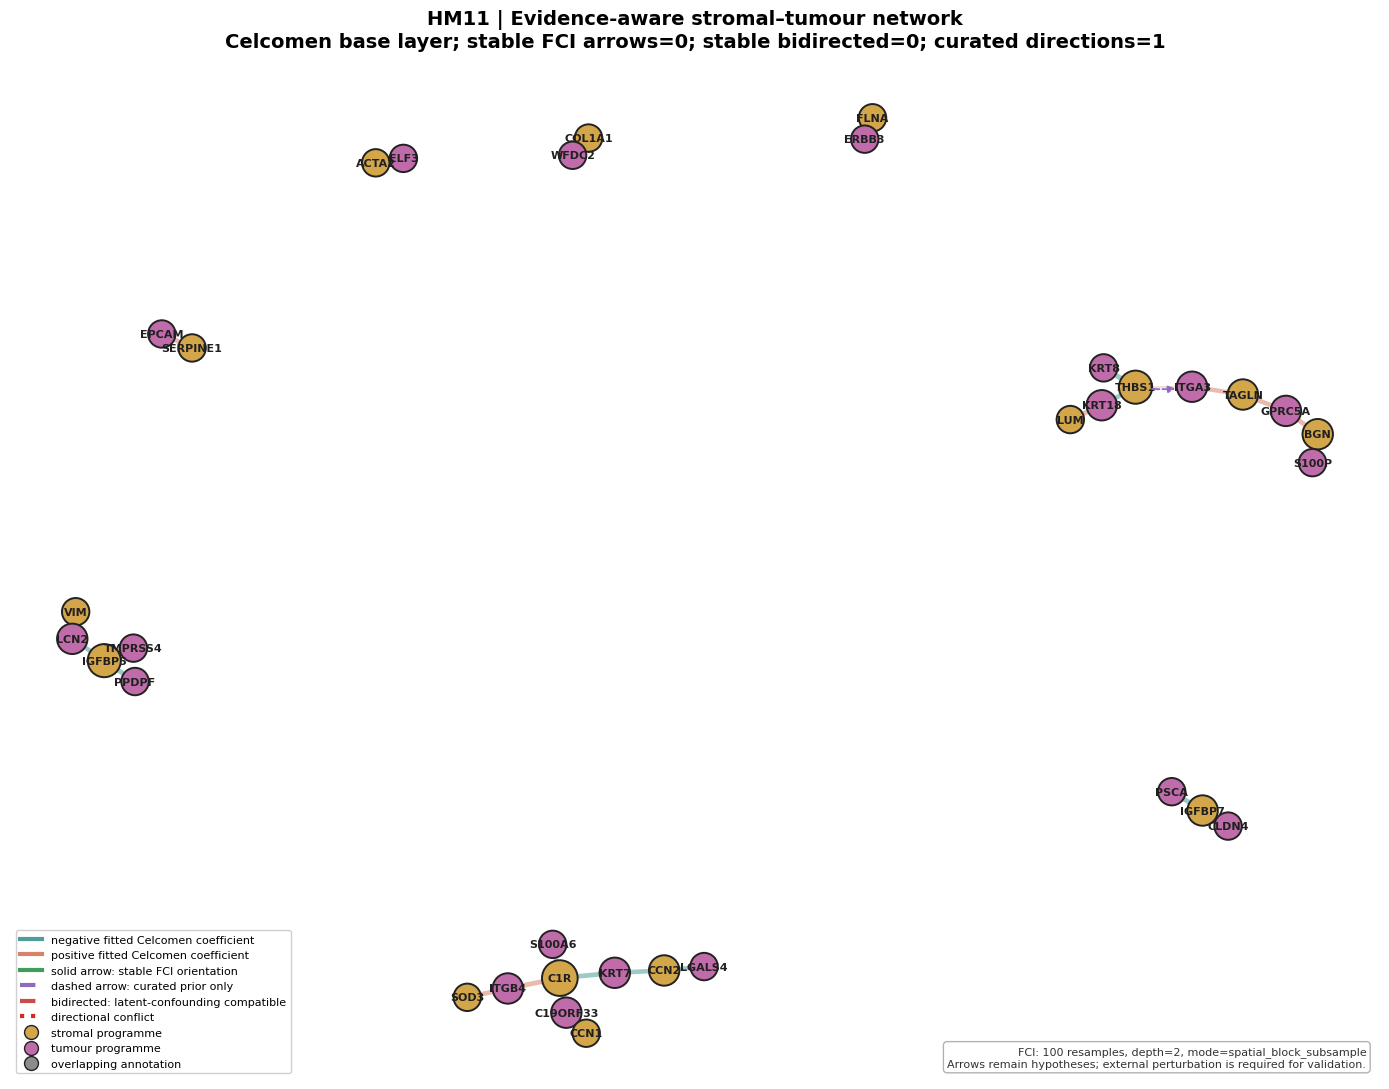

HM11 figure saved: unified_causality_spatial/FINAL_evidence_network_HM11.png


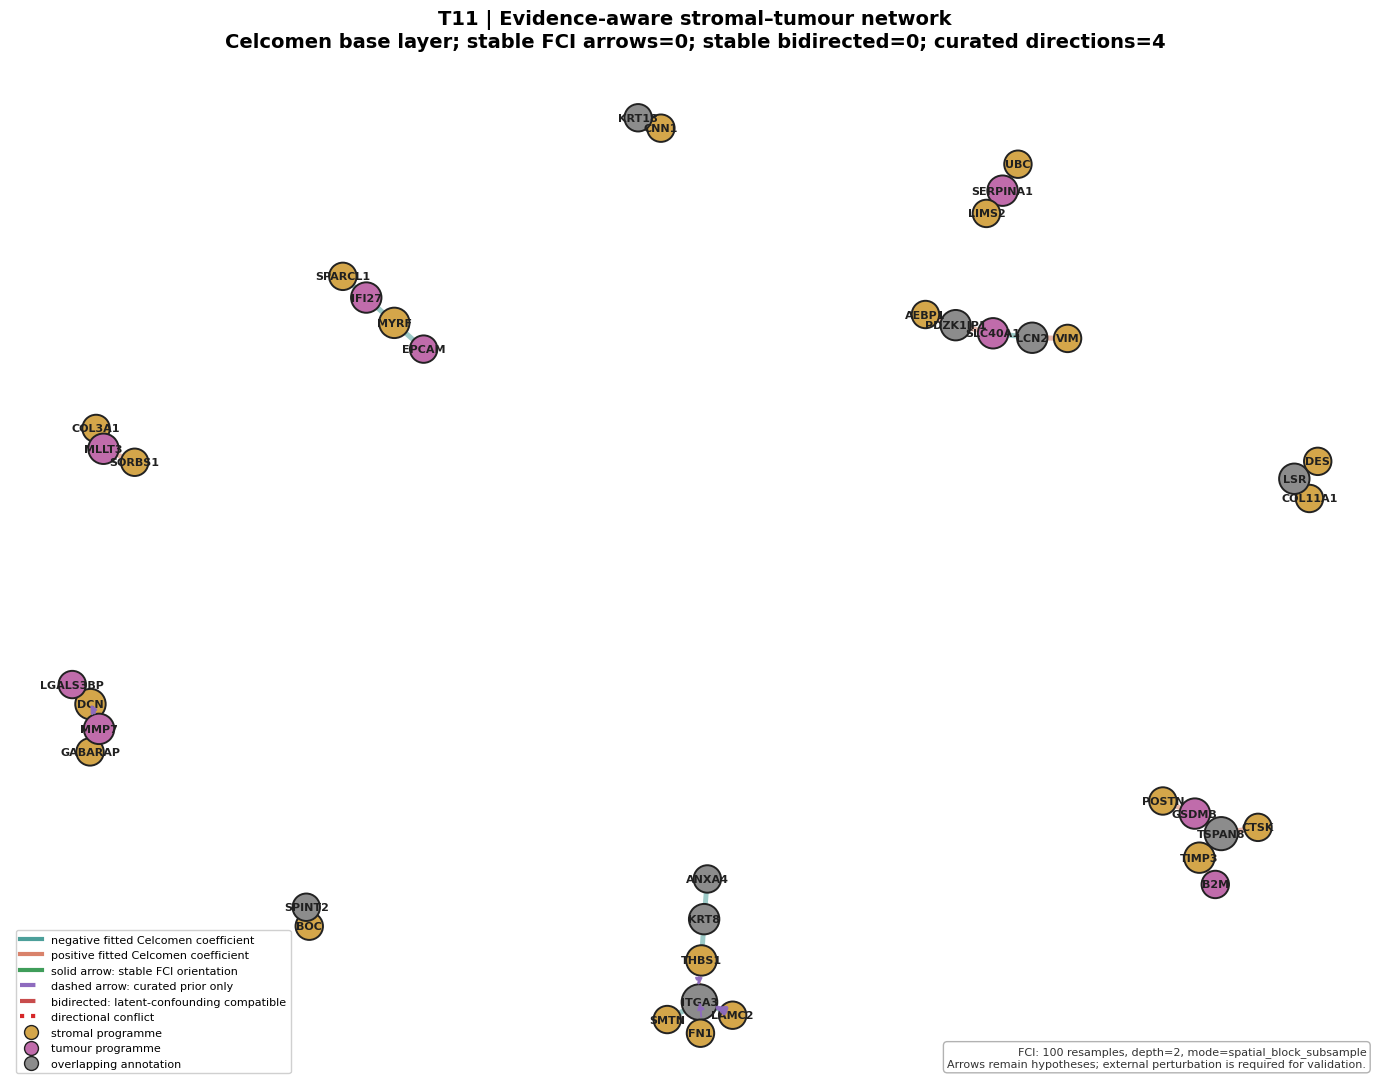

T11 figure saved: unified_causality_spatial/FINAL_evidence_network_T11.png


In [11]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

NEGATIVE_COLOUR = "#4C9F9A"
POSITIVE_COLOUR = "#D9826B"
FCI_COLOUR = "#3F9D5A"
CURATED_COLOUR = "#8E6BBE"
BIDIRECTED_COLOUR = "#C84C4C"
CONFLICT_COLOUR = "#D62728"

NODE_COLOURS = {
    "stroma": "#D4A64A",
    "tumour": "#C06CAB",
    "overlap": "#8C8C8C",
}

def role_for_gene(section, gene):
    in_stroma = gene in set(data[section]["stroma"])
    in_tumour = gene in set(data[section]["tumour"])
    if in_stroma and in_tumour:
        return "overlap"
    if in_stroma:
        return "stroma"
    if in_tumour:
        return "tumour"
    return "overlap"

def select_final_edges(df):
    base = df.sort_values("celcomen_magnitude", ascending=False).head(TOP_BASE_EDGES)
    directional = df[
        df.fci_stable_direction
        | df.fci_stable_bidirected
        | df.curated_direction.notna()
        | df.evidence_category.isin(["directional_conflict", "curated_direction_conflict"])
    ].sort_values("celcomen_magnitude", ascending=False)

    selected = pd.concat([base, directional], ignore_index=True)
    selected["pair_key"] = selected.apply(
        lambda row: canonical_pair(row.gene_a, row.gene_b), axis=1
    )
    selected = selected.drop_duplicates("pair_key")

    if len(selected) > MAX_FINAL_EDGES:
        # Always retain all directional evidence; trim only extra undirected base edges.
        required = selected[
            selected.fci_stable_direction
            | selected.fci_stable_bidirected
            | selected.curated_direction.notna()
            | selected.evidence_category.isin(["directional_conflict", "curated_direction_conflict"])
        ]
        optional = selected[~selected.pair_key.isin(required.pair_key)]
        remaining = max(0, MAX_FINAL_EDGES - len(required))
        selected = pd.concat([required, optional.head(remaining)], ignore_index=True)
    return selected

def draw_arrow(ax, positions, arrow, colour, width, linestyle="-", radius=0.08):
    source, target = parse_arrow(arrow)
    if source not in positions or target not in positions:
        return
    ax.annotate(
        "",
        xy=positions[target],
        xytext=positions[source],
        arrowprops={
            "arrowstyle": "-|>",
            "color": colour,
            "lw": width,
            "linestyle": linestyle,
            "alpha": 0.95,
            "connectionstyle": f"arc3,rad={radius}",
            "shrinkA": 12,
            "shrinkB": 12,
        },
        zorder=4,
    )

def plot_final_network(section, df):
    selected = select_final_edges(df)
    graph = nx.Graph()
    for row in selected.itertuples(index=False):
        graph.add_edge(row.gene_a, row.gene_b)

    if len(graph) == 0:
        print(f"{section}: no graphable evidence")
        return

    positions = nx.spring_layout(
        graph,
        seed=11,
        k=3.2 / np.sqrt(max(len(graph), 1)),
        iterations=250,
    )

    fig, ax = plt.subplots(figsize=(14, 11))
    degrees = dict(graph.degree())
    nodes = list(graph.nodes())
    roles = [role_for_gene(section, gene) for gene in nodes]

    nx.draw_networkx_nodes(
        graph,
        positions,
        nodelist=nodes,
        node_color=[NODE_COLOURS[role] for role in roles],
        node_size=[300 + 90 * degrees.get(gene, 0) for gene in nodes],
        edgecolors="#222222",
        linewidths=1.4,
        ax=ax,
    )
    nx.draw_networkx_labels(
        graph,
        positions,
        font_size=8,
        font_weight="bold",
        font_color="#202020",
        ax=ax,
    )

    # Base Celcomen layer: always undirected.
    for row in selected.itertuples(index=False):
        colour = NEGATIVE_COLOUR if row.celcomen_coupling < 0 else POSITIVE_COLOUR
        width = 0.7 + 3.0 * min(1.0, row.celcomen_magnitude)
        ax.plot(
            [positions[row.gene_a][0], positions[row.gene_b][0]],
            [positions[row.gene_a][1], positions[row.gene_b][1]],
            color=colour,
            linewidth=width,
            alpha=0.55,
            zorder=1,
        )

    # Evidence overlays.
    for row in selected.itertuples(index=False):
        width = 1.4 + 2.8 * min(1.0, row.celcomen_magnitude)

        if row.evidence_category in ("directional_conflict", "curated_direction_conflict"):
            ax.plot(
                [positions[row.gene_a][0], positions[row.gene_b][0]],
                [positions[row.gene_a][1], positions[row.gene_b][1]],
                color=CONFLICT_COLOUR,
                linewidth=width,
                linestyle=":",
                alpha=0.95,
                zorder=3,
            )
            continue

        if row.fci_stable_bidirected:
            ax.annotate(
                "",
                xy=positions[row.gene_b],
                xytext=positions[row.gene_a],
                arrowprops={
                    "arrowstyle": "<|-|>",
                    "color": BIDIRECTED_COLOUR,
                    "lw": width,
                    "linestyle": "--",
                    "alpha": 0.95,
                    "connectionstyle": "arc3,rad=0.12",
                    "shrinkA": 12,
                    "shrinkB": 12,
                },
                zorder=4,
            )
            continue

        if row.fci_stable_direction and isinstance(row.fci_arrow, str):
            draw_arrow(ax, positions, row.fci_arrow, FCI_COLOUR, width, linestyle="-")
        elif isinstance(row.curated_direction, str) and "->" in row.curated_direction:
            draw_arrow(ax, positions, row.curated_direction, CURATED_COLOUR, width, linestyle="--")

    stable_count = int(selected.fci_stable_direction.sum())
    bidirected_count = int(selected.fci_stable_bidirected.sum())
    curated_count = int(selected.curated_direction.notna().sum())
    mode = df.loc[df.fci_evaluated, "fci_resampling_mode"].iloc[0] if df.fci_evaluated.any() else "none"

    legend = [
        Line2D([0], [0], color=NEGATIVE_COLOUR, lw=3, label="negative fitted Celcomen coefficient"),
        Line2D([0], [0], color=POSITIVE_COLOUR, lw=3, label="positive fitted Celcomen coefficient"),
        Line2D([0], [0], color=FCI_COLOUR, lw=3, label="solid arrow: stable FCI orientation"),
        Line2D([0], [0], color=CURATED_COLOUR, lw=3, ls="--", label="dashed arrow: curated prior only"),
        Line2D([0], [0], color=BIDIRECTED_COLOUR, lw=3, ls="--", label="bidirected: latent-confounding compatible"),
        Line2D([0], [0], color=CONFLICT_COLOUR, lw=3, ls=":", label="directional conflict"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=NODE_COLOURS["stroma"],
               markeredgecolor="#222", markersize=10, label="stromal programme"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=NODE_COLOURS["tumour"],
               markeredgecolor="#222", markersize=10, label="tumour programme"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=NODE_COLOURS["overlap"],
               markeredgecolor="#222", markersize=10, label="overlapping annotation"),
    ]
    ax.legend(handles=legend, loc="lower left", fontsize=8, frameon=True, framealpha=0.92)

    ax.set_title(
        f"{section} | Evidence-aware stromal–tumour network\n"
        f"Celcomen base layer; stable FCI arrows={stable_count}; "
        f"stable bidirected={bidirected_count}; curated directions={curated_count}",
        fontsize=14,
        fontweight="bold",
        pad=18,
    )
    ax.text(
        0.99,
        0.01,
        f"FCI: {N_RESAMPLES} resamples, depth={FCI_DEPTH}, mode={mode}\n"
        "Arrows remain hypotheses; external perturbation is required for validation.",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color="#333333",
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "alpha": 0.90, "edgecolor": "#aaaaaa"},
    )
    ax.axis("off")
    fig.tight_layout()

    output = os.path.join(OUT, f"FINAL_evidence_network_{section}.png")
    fig.savefig(output, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"{section}: final graph saved to {output}")

for section in SECTIONS:
    if section in pairs:
        plot_final_network(section, pairs[section])

## 11. Final audit report

The report below summarises the executed results in plain language and uses conservative causal terminology. It distinguishes strong undirected functional candidates, stable data-derived orientations, curated-prior-only arrows, conflicts and stable bidirected patterns.

In [12]:
summary_rows = []
print("=" * 96)
print("FINAL SPATIALLY AWARE CELCOMEN–FCI CAUSAL-HYPOTHESIS AUDIT")
print("=" * 96)

for section, df in pairs.items():
    evaluated = df[df.fci_evaluated]
    resampling_mode = evaluated.fci_resampling_mode.iloc[0] if len(evaluated) else "none"
    successful = int(evaluated.fci_successful_runs.iloc[0]) if len(evaluated) else 0
    d = data[section]

    counts = df.evidence_category.value_counts().to_dict()
    summary = {
        "section": section,
        "unique_candidate_pairs": len(df),
        "targeted_fci_pairs": int(df.in_fci_panel.sum()),
        "successful_primary_fci_runs": successful,
        "resampling_mode": resampling_mode,
        "coordinate_source": d["coordinate_source"],
        "coordinate_alignment": d["coordinate_alignment"],
        "technical_covariates": "; ".join(d["technical_covariates"].columns) or "none",
        "stable_fci_directions": int(df.fci_stable_direction.sum()),
        "stable_bidirected_patterns": int(df.fci_stable_bidirected.sum()),
        "curated_supported_pairs": int((df.omnipath | df.kegg).sum()),
        "curated_consensus_directions": int(df.curated_direction.notna().sum()),
        "curated_direction_conflicts": int((df.curated_direction_status == "conflicting").sum()),
        "same_arrow_depth3": int(df.depth3_same_arrow.sum()),
        "same_arrow_expanded_panel": int(df.expanded_panel_same_arrow.sum()),
        "same_arrow_both_sensitivities": int(df.robust_to_both_sensitivities.sum()),
        "unstable_fci_signals": int((df.evidence_category == "unstable_fci_signal").sum()),
    }
    summary_rows.append(summary)

    print(f"\nSECTION {section}")
    print(f"  spatial coordinates: {d['coordinate_source']}")
    print(f"  coordinate alignment: {d['coordinate_alignment']} "
          f"({d['coordinate_alignment_detail']})")
    if d["coordinate_alignment"] == "row_order_assumed":
        print("  ALIGNMENT LIMITATION: the coordinate CSV was assumed to follow expression row order.")
    print(f"  technical covariates adjusted: {list(d['technical_covariates'].columns) or 'none'}")
    print(f"  unique Celcomen candidate pairs: {len(df)}")
    print(f"  targeted primary FCI cross-pairs: {int(df.in_fci_panel.sum())}")
    print(f"  primary FCI: {successful}/{N_RESAMPLES} successful, depth={FCI_DEPTH}, "
          f"mode={resampling_mode}")
    print(f"  stable exact FCI arrows: {int(df.fci_stable_direction.sum())}")
    print(f"  stable bidirected patterns: {int(df.fci_stable_bidirected.sum())}")
    print(f"  exact arrows repeated at depth {SENSITIVITY_DEPTH}: {int(df.depth3_same_arrow.sum())}")
    print(f"  exact arrows repeated in expanded panel: {int(df.expanded_panel_same_arrow.sum())}")
    print(f"  exact arrows robust to both checks: {int(df.robust_to_both_sensitivities.sum())}")
    print(f"  OmniPath-supported pairs: {int(df.omnipath.sum())}")
    print(f"  KEGG-supported pairs: {int(df.kegg.sum())} (KEGG status: {KEGG_STATUS})")
    print(f"  non-conflicting curated directions: {int(df.curated_direction.notna().sum())}")

    print("\n  Highest-priority evidence categories")
    for category in (
        "convergent_causal_hypothesis",
        "stable_fci_with_curated_support",
        "stable_data_orientation",
        "stable_bidirected_pattern",
        "curated_directional_prior",
        "directional_conflict",
        "unstable_fci_signal",
        "undirected_functional_candidate",
    ):
        count = counts.get(category, 0)
        if count:
            print(f"    {category:38s} {count}")

    print("\n  Strongest symmetric Celcomen relationships")
    for row in df.sort_values("celcomen_magnitude", ascending=False).head(5).itertuples(index=False):
        print(f"    {row.gene_a:10s} — {row.gene_b:10s} "
              f"{row.celcomen_coupling:+.3f} ({row.celcomen_sign})")

    stable = df[df.fci_stable_direction]
    print("\n  Stable data-derived orientations")
    if len(stable):
        for row in stable.head(10).itertuples(index=False):
            print(f"    {row.fci_arrow:25s} adjacency={row.fci_adjacency_stability:.0%}, "
                  f"directed={row.fci_directed_stability:.0%}, "
                  f"exact-arrow={row.fci_arrow_stability:.0%}, "
                  f"depth3_same={row.depth3_same_arrow}, "
                  f"expanded_same={row.expanded_panel_same_arrow}, "
                  f"curated={row.direction_relation}")
    else:
        print("    none met all prespecified 70% stability thresholds")

    curated_only = df[df.evidence_category == "curated_directional_prior"]
    print("\n  Curated-prior-only directions")
    if len(curated_only):
        for row in curated_only.head(10).itertuples(index=False):
            print(f"    {row.curated_direction:25s} source={row.db_source}; "
                  f"|Celcomen|={row.celcomen_magnitude:.3f}")
    else:
        print("    none among top-decile Celcomen relationships")

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUT, "FINAL_analysis_summary.csv")
summary_df.to_csv(summary_path, index=False)
print("\n" + "=" * 96)
print("Summary table:", summary_path)
print("Final figures:")
for section in pairs:
    print(" ", os.path.join(OUT, f"FINAL_evidence_network_{section}.png"))
print("Interpret all arrows as hypotheses. Target-specific external perturbation with biological")
print("replication is required for causal validation.")

FINAL SPATIALLY AWARE CELCOMEN–FCI CAUSAL-HYPOTHESIS AUDIT

HM11
  Spatial alignment: verified against the original H5AD barcode order.
  Expression spots: 3,921
  Unique Celcomen candidate pairs: 754
  Targeted FCI stromal–tumour pairs: 81
  Primary spatial FCI: 100/100 successful, depth=2
  Stable exact FCI arrows: 0
  Stable bidirected patterns: 0
  Exact arrows retained in depth-3 sensitivity: 0
  Exact arrows retained in expanded-panel sensitivity: 0
  OmniPath-supported candidate pairs: 1
  KEGG-supported candidate pairs: 0

  Evidence categories:
    unstable FCI signals: 10
    strong undirected functional candidates: 66

  Strongest symmetric Celcomen relationships:
    THBS1 — KRT8      -1.000
    VIM — LCN2        +0.998
    BGN — S100P       +0.997
    COL1A1 — WFDC2    -0.935
    IGFBP5 — PPDPF    -0.929

T11
  Spatial alignment: verified against the original H5AD barcode order.
  Expression spots: 2,768
  Unique Celcomen candidate pairs: 3,263
  Targeted FCI stromal–tumou

## Final interpretation

The executed analysis identified strong **undirected** Celcomen relationships between stromal- and tumour-programme genes in both HM11 and T11. FCI was then applied independently to a prespecified 9+9 gene panel without imposing a stromal-to-tumour direction. Although many provisional arrows appeared in individual resamples, no exact arrow met all three prespecified 70% criteria for adjacency, directed endpoint type and exact orientation. No stable bidirected pattern was identified either, and no exact direction was retained by the depth-3 or expanded-panel sensitivity analyses.

The database layer supplied one OmniPath-supported candidate pair in HM11 and four in T11, but none formed a convergent hypothesis combining a top-decile Celcomen relationship, a stable FCI orientation and concordant curated direction. The result is therefore a negative causal-orientation finding: the current data prioritise functional candidates but do not resolve a reproducible causal direction.

## Limitations

This remains a targeted observational analysis of two spatial tissue sections rather than independent biological replication. Spatial-block resampling and spatial residualisation reduce, but do not eliminate, spatial dependence and confounding. No additional technical covariates were available in the spot tables, the primary FCI search was depth-limited, and the candidate panel was prespecified rather than genome-wide. Omitted genes, cell-type composition and unmeasured tissue states may influence the inferred graph. Celcomen coefficients are symmetric model outputs, while OmniPath and KEGG directions are context-general curated priors. Consequently, the final networks should be interpreted as evidence-annotated causal hypotheses requiring target-specific perturbation and independent validation.

## References

